# GISLR · Stage 2 — model evaluation & Kaggle submission

**The single place where all GISLR model evaluation and submission happens.** The four
`gislr.1.model.*.ipynb` notebooks train and stop; everything after a trained checkpoint —
leaderboard, learning curves, confusion matrices, TFLite export, Kaggle submission — is here
(TODO §6). This is a **pipeline stage**, not a diagnostic: it consumes the run registry and
writes back into it.

**How runs are queried.** DuckDB globs every `data/models/*/meta.json` directly
(`modules.model.submission`), so the leaderboard is a query over the run records themselves.
`data/models/index.csv` stays the *committed snapshot* of that query, never the query path —
it can be stale without breaking anything here.

**Ranking metric.** `accuracy = COALESCE(overall_accuracy, train_val_acc)`: the canonical
per-class eval when a run has one, otherwise the training-loop best val accuracy. Identical
to `build_model_index.py`'s `val_acc`, so the two can't disagree. Only canonical numbers are
leaderboard-legal (same split, same metric — §2 backfills the rest).

**Artifacts produced**

| artifact | path |
|---|---|
| canonical eval per run (§2) | `data/models/<run_id>/assets/{per_class_accuracy.csv,eval_summary.json,val_predictions.npz}` |
| top-5 learning-curve overlay | `data/cache/gislr/evaluation/top5_learning_curves.png` |
| per-run confusion matrices (top 5) | `data/cache/gislr/evaluation/confusion_<run_id>.png` |
| aggregate normalized confusion matrix | `data/cache/gislr/evaluation/confusion_all_normalized.{png,npy}` |
| most-confused class pairs | `data/cache/gislr/evaluation/confused_pairs.csv` |
| TFLite export + submission zip per run (§6) | `data/models/<run_id>/export/{model.tflite,submission.zip}` |
| submission state per run (§7) | `data/models/<run_id>/meta.json` → `submission` block |

**Resumability** — §2 skips runs already evaluated (`eval_status == "canonical"`) and §6 skips
runs already exported, so both cells are safe to interrupt and re-run; neither ever redoes
finished work. §7 is idempotent by construction: a submitted run is marked `tested` and drops
out of the queue.

**Design decisions**

- **Confusion matrices are built from `assets/val_predictions.npz`**, written by the canonical
  eval — never by re-running inference here. One inference pass per run, ever.
- **The aggregate matrix is normalized and averaged over *all* evaluated runs.** Where
  independently-trained architectures make the *same* mistake, that confusion is a property of
  the data/labels rather than of any one model — which is exactly the Phase-1 diagnostic the
  plateau workstream needs (TODO §7.1).
- **Submission state lives in `meta.json`** (schema v3, `submission.tested`), deliberately
  dataset-agnostic — `tested` means "scored on the official/held-out test set", so POPSIGN runs
  reuse the block without inheriting Kaggle vocabulary.
- **The submission queue is a query**, `dataset = 'gislr' AND tested = false LIMIT 100`, so each
  pass submits only untested models and respects the 100/day cap by construction rather than by
  bookkeeping.

**Kernel requirements**: project `.venv`, CWD = `src/`. §2 needs a CUDA GPU (inference);
§7 needs `tensorflow`; §8 needs the `kaggle` CLI.

## 1. Setup

All imports and every shared tunable. Later sections re-derive their inputs from disk, so
after running this cell any single cell below can be re-run on its own.

In [ ]:
# ============================================================
# Setup — imports, tunables, resolved paths
# ============================================================
# import json
# import subprocess
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from modules.model import registry as R
from modules.model import export as EX
from modules.model import submission as SUB
from modules.model.report import confusion_matrix, load_history, plot_confusion
from modules.paths import CACHE_DIR, MODELS_DIR, gislr_dir
from modules.model import load_label_map

DATASET = "gislr"          # every query in this notebook is scoped to one dataset
TOP_N = 5                  # how many runs the "top" sections cover
CONFUSED_PAIRS = 30        # most-confused class pairs to extract (TODO §7.1)
FIG_DPI = 110

EVAL_DIR = CACHE_DIR / "gislr" / "evaluation"   # derived artifacts (reusable) -> cache
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# label map: index -> sign name, for readable confusion-matrix axes
DATA_DIR = gislr_dir()
SIGN2IDX = load_label_map(DATA_DIR)
IDX2SIGN = {v: k for k, v in SIGN2IDX.items()}
SIGNS = [IDX2SIGN[i] for i in range(len(IDX2SIGN))]

print(f"MODELS_DIR = {MODELS_DIR}")
print(f"EVAL_DIR   = {EVAL_DIR}")
print(f"meta glob  = {R.META_GLOB}")
print(f"{len(SIGNS)} classes · schema v{R.SCHEMA_VERSION}")

MODELS_DIR = C:\Users\user2\sign2speech\src\data\models
EVAL_DIR   = C:\Users\user2\sign2speech\src\data\cache\gislr\evaluation
meta glob  = C:\Users\user2\sign2speech\src\data\models\*\meta.json
250 classes · schema v3


## 2. Leaderboard — every GISLR run, ordered by accuracy (TODO §6.1)

DuckDB reads all `meta.json` files and returns one row per run, best first. `eval_status`
tells you whether a row is leaderboard-legal (`canonical`, from `eval_gru.py` on the canonical
split) or provisional (`pending`, the training loop's own val accuracy) — §3 promotes the
pending ones.

`tested` is the schema-v3 submission flag: whether this run has been scored on the official
Kaggle test set (§8).

In [2]:
# ============================================================
# Leaderboard over data/models/*/meta.json (tunables: SHOW_COLUMNS, MIN_ACC)
# Pure query — re-run any time; reads nothing but the run records.
# ============================================================
SHOW_COLUMNS = ["run_id", "architecture", "subset", "coords", "accuracy", "eval_status",
                "macro_accuracy", "median_class_accuracy", "n_classes_below_50pct",
                "n_params", "streaming", "tested", "regime", "wall_time_min"]
MIN_ACC = 0.0   # raise to hide obviously broken runs

board = SUB.leaderboard(DATASET)
board = board[board["accuracy"].fillna(0) >= MIN_ACC].reset_index(drop=True)

print(f"{len(board)} {DATASET} runs · "
      f"{int((board['eval_status'] == 'canonical').sum())} canonical · "
      f"{int(board['tested'].sum())} already submitted\n")
with pd.option_context("display.width", 220, "display.max_columns", None):
    display(board[SHOW_COLUMNS].head(20))

# per-architecture best — the architecture comparison the plateau analysis rests on
best_per_arch = (board.sort_values("accuracy", ascending=False)
                 .groupby("architecture", as_index=False).first()
                 .sort_values("accuracy", ascending=False))
print("\nbest run per architecture:")
display(best_per_arch[["architecture", "run_id", "subset", "coords",
                       "accuracy", "eval_status", "n_params", "streaming"]])

36 gislr runs · 18 canonical · 0 already submitted



,run_id,architecture,subset,coords,accuracy,eval_status,macro_accuracy,median_class_accuracy,n_classes_below_50pct,n_params,streaming,tested,regime,wall_time_min
0,1784447175,bilstm,ME_126,xy,0.756900,pending,NaN,NaN,<NA>,2751218,False,False,v2-plateau-300,35.7
1,1784447187,gru,ME_126,xy,0.756600,pending,NaN,NaN,<NA>,851698,True,False,v2-plateau-300,43.0
2,1784453891,gru,ME_126,xy,0.756600,pending,NaN,NaN,<NA>,851698,True,False,v2-plateau-300,11.4
3,1784397301,bilstm,FP_118,xy,0.752540,canonical,0.750101,0.763158,10,2718418,False,False,v2-plateau-300,21.0
4,1784455294,gru,FP_118,xy,0.750600,pending,NaN,NaN,<NA>,839378,True,False,v2-plateau-300,11.1
5,1784451456,gru,FP_118,xy,0.750600,pending,NaN,NaN,<NA>,839378,True,False,v2-plateau-300,26.6
6,1784395799,bilstm,ME_126,xy,0.750423,canonical,0.748323,0.763932,10,2751218,False,False,v2-plateau-300,11.9
7,1784454580,gru,ME_132,xy,0.749500,pending,NaN,NaN,<NA>,860938,True,False,v2-plateau-300,11.8
8,1784449770,gru,ME_132,xy,0.749500,pending,NaN,NaN,<NA>,860938,True,False,v2-plateau-300,28.0
9,1784459026,bilstm,ME_132,xy,0.747600,pending,NaN,NaN,<NA>,2775818,False,False,v2-plateau-300,13.1



best run per architecture:


,architecture,run_id,subset,coords,accuracy,eval_status,n_params,streaming
0,bilstm,1784447175,ME_126,xy,0.756900,pending,2751218,False
2,gru,1784447187,ME_126,xy,0.756600,pending,851698,True
3,lstm,1784455964,ME_126,xy,0.746000,pending,1113842,True
1,cnn1d,1784400020,ME_132,xy,0.541384,canonical,732426,True


## 3. Canonical eval backfill

A run is only comparable — and can only have a confusion matrix — once
`modules/scripts/eval_gru.py` has evaluated it on the canonical split (stratified 90/10,
seed 42, 9,448 videos). This cell runs that eval **in-process** for every run still marked
`pending`, writing `assets/val_predictions.npz` along the way.

Resumable and skip-if-done: already-canonical runs are never re-evaluated, so interrupting
this cell costs at most the run in flight. ~9,448 videos of GPU inference per run.

In [3]:
# ============================================================
# Backfill canonical evals for runs still marked "pending"
# (tunables: EVAL_LIMIT, FORCE_RUN_IDS). Needs a CUDA GPU.
# Skip-if-done — safe to interrupt and re-run.
# ============================================================
EVAL_LIMIT = None        # cap how many runs this pass evaluates (None = all pending)
FORCE_RUN_IDS = []       # re-evaluate these run_ids even if already canonical

from modules.scripts.eval_gru import evaluate_run

pending = SUB.query_runs(
    where=f"dataset = '{DATASET}' AND metrics.eval_status <> 'canonical'",
    order_by="accuracy DESC NULLS LAST")
todo = [int(r) for r in pending["run_id"]] + [int(r) for r in FORCE_RUN_IDS]
todo = list(dict.fromkeys(todo))[:EVAL_LIMIT]

# a run whose weights are gone (checkpoints are gitignored) can never be evaluated —
# report it rather than failing the whole pass
missing = [r for r in todo if not (MODELS_DIR / str(r) / R.CKPT_BEST).is_file()]
todo = [r for r in todo if r not in missing]
if missing:
    print(f"skipping {len(missing)} run(s) with no {R.CKPT_BEST} on disk: {missing}\n")

bar = tqdm(todo, desc="canonical eval", dynamic_ncols=True)
results = {}
for run_id in bar:
    bar.set_postfix_str(f"run {run_id}")
    summary = evaluate_run(MODELS_DIR / str(run_id), verbose=False)
    results[run_id] = summary
    bar.set_postfix_str(f"run {run_id} · overall {summary['overall_accuracy']:.4f}")
bar.close()

if results:
    display(pd.DataFrame(results).T[["overall_accuracy", "macro_accuracy",
                                     "median_class_accuracy", "n_classes_below_50pct"]])
    print("\nrebuild the committed index snapshot:")
    print(".venv/Scripts/python.exe src/modules/scripts/build_model_index.py")
else:
    print("nothing pending — every run with weights on disk is already canonical")

canonical eval:   0%|          | 0/18 [00:00<?, ?it/s]

,overall_accuracy,macro_accuracy,median_class_accuracy,n_classes_below_50pct
1784447175,0.75688,0.754883,0.772811,7
1784447187,0.756456,0.754684,0.756757,8
1784453891,0.756456,0.754684,0.756757,8
1784455294,0.750529,0.748623,0.756757,8
1784451456,0.750529,0.748623,0.756757,8
1784454580,0.749259,0.747301,0.766968,7
1784449770,0.749259,0.747301,0.766968,7
1784459026,0.747566,0.745459,0.763158,11
1784447190,0.745978,0.743664,0.753378,9
1784455964,0.745978,0.743664,0.753378,9



rebuild the committed index snapshot:
.venv/Scripts/python.exe src/modules/scripts/build_model_index.py


## 4. Learning curves — best 5 models overlaid

One figure, all five runs: loss on the left, accuracy on the right, train dashed and val
solid. Overlaying them is what makes the plateau visible as a *shared* ceiling rather than a
per-model quirk — and the train-vs-val gap per run is the Phase-1 overfitting/underfitting
call (TODO §7.1).

Curves come from each run's `assets/history.json`; for runs trained before that asset existed,
`load_history` falls back to `last.pt` and backfills the JSON.

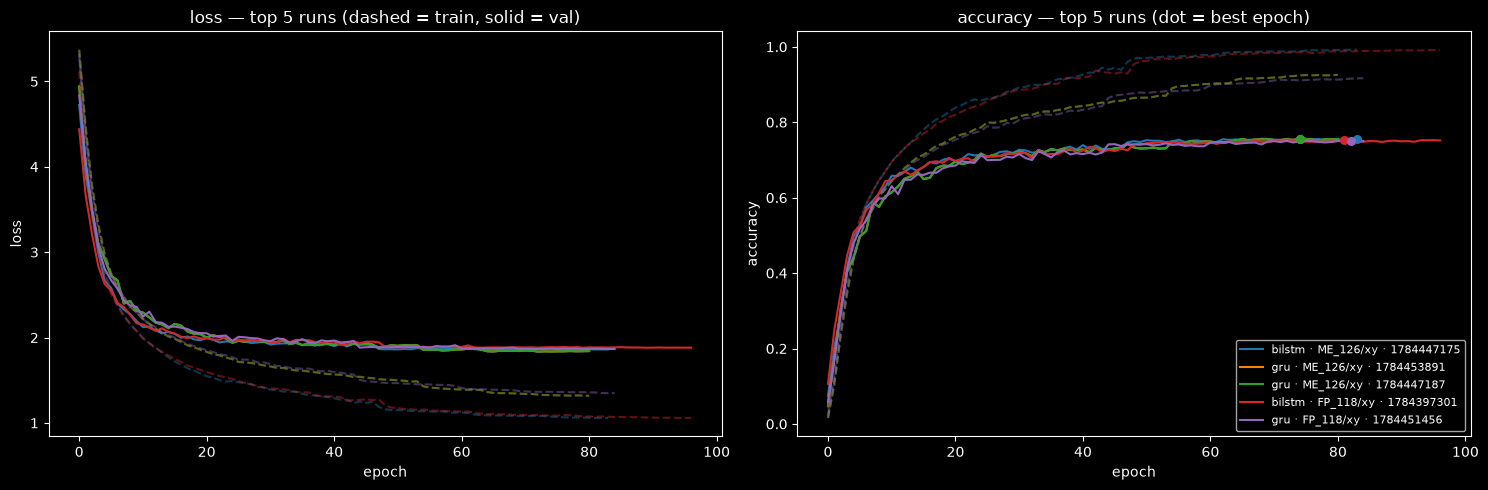

,run_id,architecture,subset,best_epoch,train_acc,val_acc,train_val_gap
0,1784447175,bilstm,ME_126/xy,84,0.9922,0.7569,0.2354
1,1784453891,gru,ME_126/xy,75,0.9242,0.7566,0.1677
2,1784447187,gru,ME_126/xy,75,0.9242,0.7566,0.1677
3,1784397301,bilstm,FP_118/xy,82,0.9886,0.7526,0.2360
4,1784451456,gru,FP_118/xy,83,0.9158,0.7506,0.1651


train >> val  => overfitting: prioritize augmentation/regularization (TODO §7.4)
train ~= val  => underfitting the signal: prioritize normalization + motion (TODO §7.2/§7.3)


In [4]:
# ============================================================
# Overlay learning curves of the top-N runs (tunables: TOP_N, RUN_IDS)
# Reads assets/history.json per run — no dependency on other cells.
# ============================================================
RUN_IDS = None  # None = top TOP_N from the leaderboard; or pass an explicit list

board = SUB.leaderboard(DATASET)
run_ids = RUN_IDS or [int(r) for r in board["run_id"].head(TOP_N)]
meta_by_id = {rid: R.load_meta(MODELS_DIR / str(rid)) for rid in run_ids}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = plt.cm.tab10(np.linspace(0, 1, 10))
gaps = []
for i, rid in enumerate(run_ids):
    try:
        h = load_history(MODELS_DIR / str(rid))
    except FileNotFoundError as e:
        print(f"skipped: {e}")
        continue
    m = meta_by_id[rid]
    label = f"{m['architecture']} · {m['subset']}/{m['coords']} · {rid}"
    c = colors[i % 10]
    axes[0].plot(h["val_loss"], color=c, label=label)
    axes[0].plot(h["train_loss"], color=c, ls="--", alpha=0.45)
    axes[1].plot(h["val_acc"], color=c, label=label)
    axes[1].plot(h["train_acc"], color=c, ls="--", alpha=0.45)
    best = int(np.argmax(h["val_acc"]))
    axes[1].scatter([best], [h["val_acc"][best]], color=c, zorder=5, s=30)
    gaps.append(
        {
            "run_id": rid,
            "architecture": m["architecture"],
            "subset": f"{m['subset']}/{m['coords']}",
            "best_epoch": best + 1,
            "train_acc": round(h["train_acc"][best], 4),
            "val_acc": round(h["val_acc"][best], 4),
            "train_val_gap": round(h["train_acc"][best] - h["val_acc"][best], 4),
        }
    )

axes[0].set_title(f"loss — top {len(run_ids)} runs (dashed = train, solid = val)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[1].set_title(f"accuracy — top {len(run_ids)} runs (dot = best epoch)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(EVAL_DIR / "top5_learning_curves.png", dpi=FIG_DPI)
plt.show()

# train/val gap at the best epoch — TODO §7.1 step 2 (the overfit/underfit verdict)
gap_df = (
    pd.DataFrame(gaps).sort_values("val_acc", ascending=False).reset_index(drop=True)
)
gap_df.to_csv(EVAL_DIR / "train_val_gap.csv", index=False)
display(gap_df)
print(
    "train >> val  => overfitting: prioritize augmentation/regularization (TODO §7.4)"
)
print(
    "train ~= val  => underfitting the signal: prioritize normalization + motion (TODO §7.2/§7.3)"
)

## 5. Confusion matrices — top 5 models individually

One 250×250 row-normalized matrix per top run, built from that run's `val_predictions.npz`.
Row *i* = true class *i*, so each row sums to 1 and the diagonal is the class's recall;
off-diagonal mass is where it goes wrong. Displayed with a log-scaled color map because
off-diagonal cells are 1–2 orders of magnitude smaller than the diagonal and would otherwise
be invisible.

Full-size PNGs go to `data/cache/gislr/evaluation/`; only the figures are shown inline.

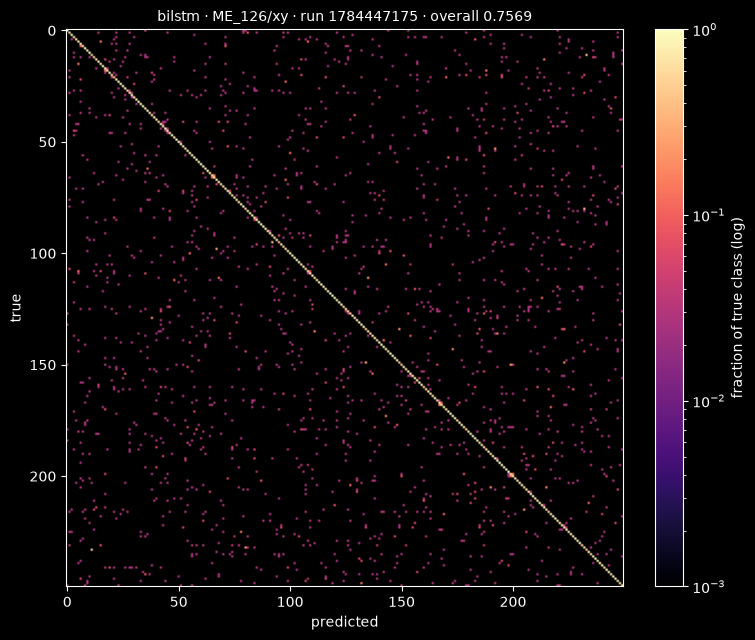

  weakest classes: give 0.34, beside 0.39, mouth 0.44, awake 0.45, wake 0.45, on 0.46, nap 0.49, jeans 0.50


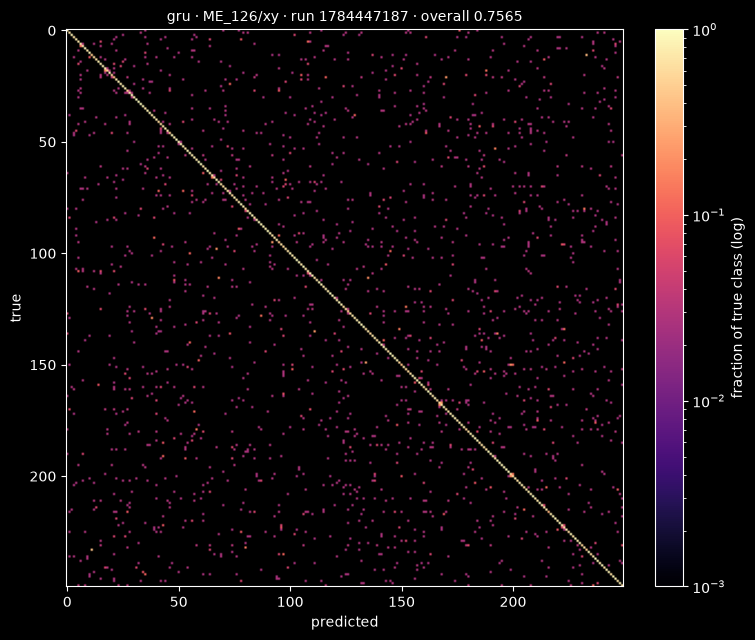

  weakest classes: there 0.33, beside 0.35, nap 0.41, jeans 0.45, awake 0.45, wake 0.45, give 0.46, close 0.49


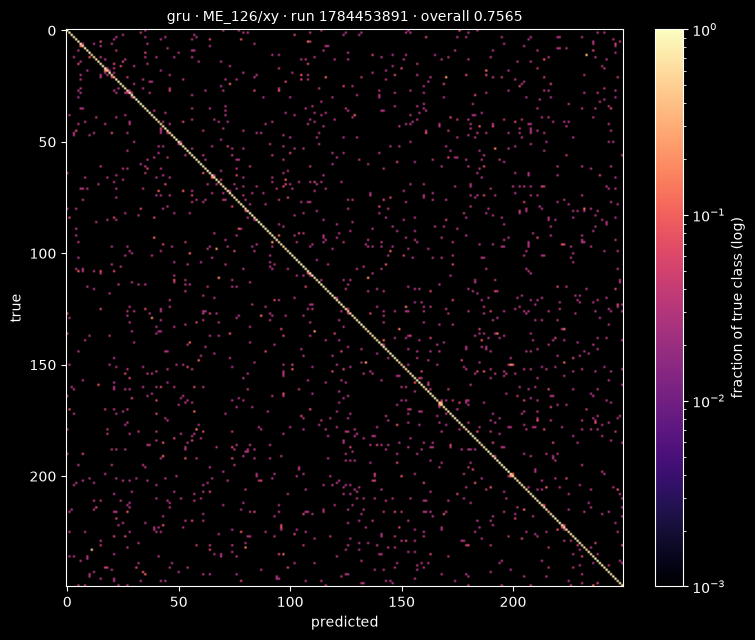

  weakest classes: there 0.33, beside 0.35, nap 0.41, jeans 0.45, awake 0.45, wake 0.45, give 0.46, close 0.49


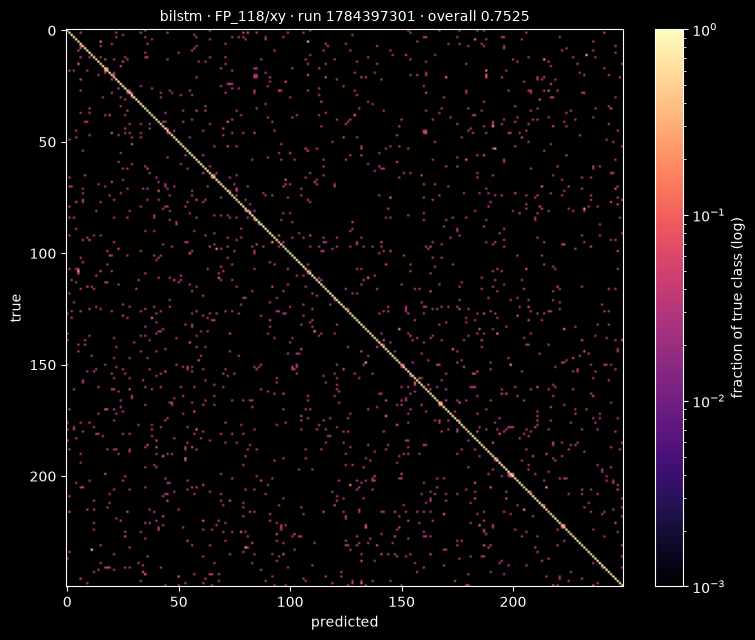

  weakest classes: give 0.34, there 0.36, nap 0.38, beside 0.42, puppy 0.44, wake 0.45, close 0.46, boat 0.46


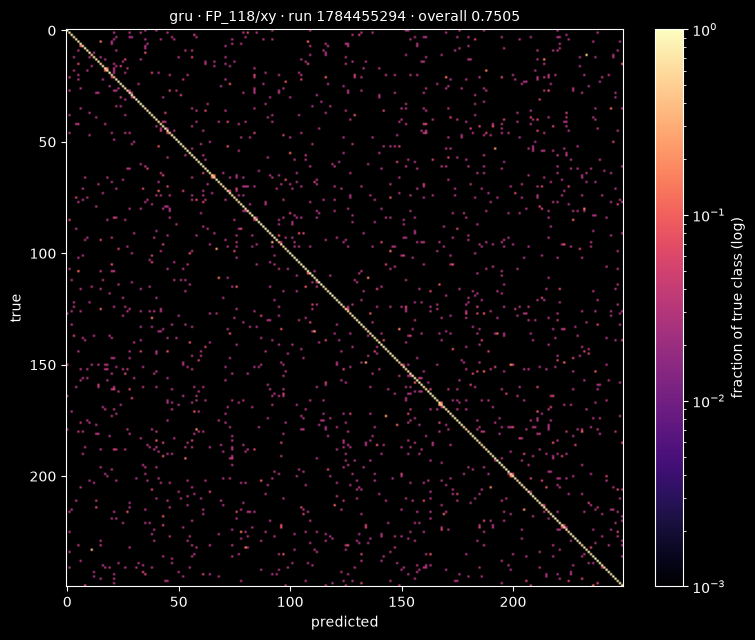

  weakest classes: give 0.31, beside 0.39, awake 0.40, nap 0.41, mouth 0.46, puppy 0.47, there 0.47, before 0.49


In [5]:
# ============================================================
# Per-run confusion matrices for the top-N runs (tunables: TOP_N, RUN_IDS)
# Built from assets/val_predictions.npz — no inference here.
# ============================================================
# confusion_matrix / plot_confusion come from modules/model/report.py — shared with
# §6, so neither cell depends on the other having been run
RUN_IDS = None    # None = top TOP_N from the leaderboard

board = SUB.leaderboard(DATASET)
evaluated = board[board["eval_status"] == "canonical"]
run_ids = RUN_IDS or [int(r) for r in evaluated["run_id"].head(TOP_N)]
if not run_ids:
    print("no canonical runs yet — run §3 first")

for rid in run_ids:
    run_dir = MODELS_DIR / str(rid)
    m = R.load_meta(run_dir)
    try:
        cm = confusion_matrix(run_dir, n_classes=m["n_classes"])
    except FileNotFoundError as e:
        print(f"skipped: {e}")
        continue
    acc = m["metrics"]["overall_accuracy"]
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = plot_confusion(cm, f"{m['architecture']} · {m['subset']}/{m['coords']} · "
                            f"run {rid} · overall {acc:.4f}", ax)
    fig.colorbar(im, ax=ax, fraction=0.046, label="fraction of true class (log)")
    fig.tight_layout()
    fig.savefig(EVAL_DIR / f"confusion_{rid}.png", dpi=FIG_DPI)
    plt.show()

    worst = np.argsort(np.diag(cm))[:8]
    print("  weakest classes: " + ", ".join(
        f"{SIGNS[i]} {np.diag(cm)[i]:.2f}" for i in worst))

## 6. Aggregate confusion matrix — all evaluated models

The mean of the row-normalized matrices of **every** canonically-evaluated GISLR run. Averaging
normalized matrices (rather than pooling raw counts) weights each model equally regardless of
how many it got right, so the result reads as "how do models *in general* confuse these
classes".

**Why this is the useful one.** A confusion that survives averaging across independently
trained GRUs, LSTMs, BiLSTMs and CNNs is not an artifact of any architecture — it is a
property of the data, the labels, or the landmark representation. That is precisely the class
of problem the plateau workstream is chasing (TODO §7.1), and it is what the confused-pair
table below feeds.

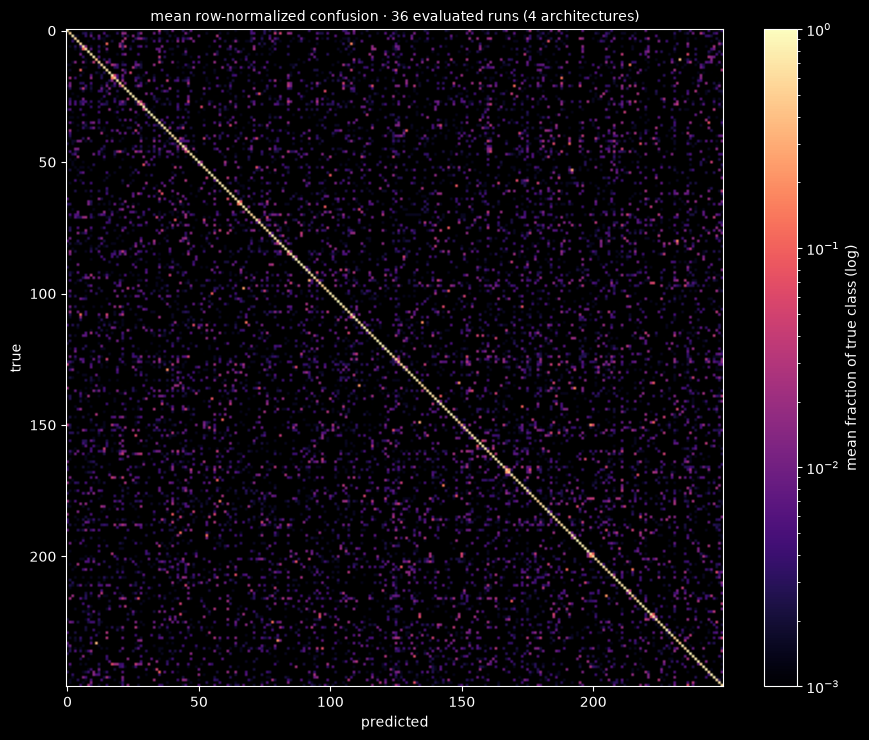

runs included: [1784447175, 1784447187, 1784453891, 1784397301, 1784455294, 1784451456, 1784395799, 1784454580, 1784449770, 1784459026, 1784396516, 1784393064, 1784447190, 1784455964, 1784399741, 1784450082, 1784456692, 1784393683, 1784400832, 1784394315, 1784459817, 1784387336, 1784390290, 1784402251, 1784457430, 1784451842, 1784385530, 1784388482, 1784389439, 1784386490, 1784400020, 1784451163, 1784449360, 1784447182, 1784399151, 1784401260]

top 30 confused pairs (mean over models) — TODO §7.1 step 4:


,true,predicted,mean_rate,true_recall,symmetric_rate
0,awake,wake,0.3840,0.4069,0.3833
1,wake,awake,0.3833,0.4465,0.3840
2,give,gift,0.2984,0.3183,0.0548
3,mouth,lips,0.2913,0.4266,0.2063
4,cut,scissors,0.2530,0.5398,0.1164
5,goose,duck,0.2407,0.6239,0.0860
6,pencil,pen,0.2279,0.5349,0.1618
7,listen,hear,0.2143,0.6541,0.1917
8,nap,sleep,0.2073,0.3390,0.0577
9,lips,mouth,0.2063,0.5361,0.2913


Next (TODO §7.1 step 5): inspect example sequences per pair and classify each as
handshape-only / motion-only / body-location — that choice decides §7.2 vs §7.3.


In [6]:
# ============================================================
# Aggregate normalized confusion matrix + most-confused pairs
# (tunables: CONFUSED_PAIRS, INCLUDE_ARCHS)
# ============================================================
INCLUDE_ARCHS = None   # None = every architecture; or e.g. ["gru", "lstm", "cnn1d"]

board = SUB.leaderboard(DATASET)
evaluated = board[board["eval_status"] == "canonical"]
if INCLUDE_ARCHS:
    evaluated = evaluated[evaluated["architecture"].isin(INCLUDE_ARCHS)]

mats, used = [], []
for rid in evaluated["run_id"]:
    try:
        mats.append(confusion_matrix(MODELS_DIR / str(int(rid))))
        used.append(int(rid))
    except FileNotFoundError:
        continue
assert mats, "no evaluated runs with cached predictions — run §3 first"

cm_all = np.mean(mats, axis=0)
np.save(EVAL_DIR / "confusion_all_normalized.npy", cm_all)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = plot_confusion(cm_all, f"mean row-normalized confusion · {len(used)} evaluated runs "
                            f"({evaluated['architecture'].nunique()} architectures)", ax)
fig.colorbar(im, ax=ax, fraction=0.046, label="mean fraction of true class (log)")
fig.tight_layout()
fig.savefig(EVAL_DIR / "confusion_all_normalized.png", dpi=FIG_DPI)
plt.show()

# most-confused ordered pairs: highest off-diagonal mass, averaged over models
off = cm_all.copy()
np.fill_diagonal(off, 0.0)
flat = np.argsort(off, axis=None)[::-1][:CONFUSED_PAIRS]
pairs = pd.DataFrame([
    {"true": SIGNS[i], "predicted": SIGNS[j],
     "mean_rate": round(float(off[i, j]), 4),
     "true_recall": round(float(cm_all[i, i]), 4),
     "symmetric_rate": round(float(off[j, i]), 4)}
    for i, j in (np.unravel_index(k, off.shape) for k in flat)
])
pairs.to_csv(EVAL_DIR / "confused_pairs.csv", index=False)
print(f"runs included: {used}\n")
print(f"top {CONFUSED_PAIRS} confused pairs (mean over models) — TODO §7.1 step 4:")
display(pairs)
print("Next (TODO §7.1 step 5): inspect example sequences per pair and classify each as")
print("handshape-only / motion-only / body-location — that choice decides §7.2 vs §7.3.")

## 7. TFLite export — the Kaggle submission artifact (TODO §6.2)

**Run this before §8** — the submission queue skips any run without a `submission.zip`.

`modules/model/export.py` runs the full chain per run: Keras rebuild → parity → frozen
SavedModel → TFLite → validation → `submission.zip`.

**Route: native Keras rebuild, not ONNX.** PyTorch → ONNX → `onnx2tf` was tried first and
abandoned (measured 2026-07-19): onnx2tf declares no dependencies of its own, cannot convert
the `IsInf` op `torch.nan_to_num` emits, permutes 3D input layouts, and fails outright on the
GRU, BiLSTM and CNN graphs. `modules/model/keras_export.py` instead rebuilds each architecture
with native Keras layers and transfers the trained weights — Keras' recurrent layers are on
TFLite's well-supported conversion path. All four architectures now export.

**Two parity gates, because weight transfer can fail silently.** A gate-order or bias-convention
mistake between PyTorch and Keras would convert cleanly and predict garbage, so export refuses
to write anything unless:

1. `keras_parity` — the Keras rebuild matches `forward_full` on the same input (~4e-6), and
2. `tflite_parity` — the **final .tflite file** matches PyTorch through the whole deployed path,
   raw `(T, 543, 3)` frames with NaNs in (~4e-6).

The second one already caught a real bug: `tf.lite.Optimize.DEFAULT` quantizes weights to int8
and shifted logits by ~1e-1, so quantization is off by default (these models are 3–11 MB against
a 40 MB cap, so it bought nothing).

The exported graph owns its preprocessing: NaN→0 and the landmark-subset gather are *inside* it,
and xy-trained runs drop the z column internally, so the grader's raw frames work unchanged for
every run regardless of subset or coordinate config.

**Caveat**: the exported model consumes the full sequence, while training/eval uniformly
subsample past `MAX_SEQ_LEN = 128` frames. Verify behaviour on long videos before trusting a
submission.

Requires `tensorflow` (declared in `pyproject.toml` — `uv sync` if imports fail, never ad-hoc
`uv pip install`).

In [7]:
# ============================================================
# Export runs to TFLite + submission.zip (tunables: EXPORT_RUN_IDS, EXPORT_LIMIT)
# Skip-if-exported — safe to interrupt and re-run.
# ============================================================
EXPORT_RUN_IDS = None    # None = the untested queue (§8's input); or an explicit list
EXPORT_LIMIT = 5         # cap per pass — the chain takes ~1-2 min/run
REEXPORT = False         # True = redo runs that already have a submission.zip

if EXPORT_RUN_IDS is None:
    queue = SUB.untested_runs(DATASET, limit=SUB.DAILY_LIMIT)
    EXPORT_RUN_IDS = [int(r) for r in queue["run_id"]]

todo = []
for rid in EXPORT_RUN_IDS[:EXPORT_LIMIT]:
    run_dir = MODELS_DIR / str(rid)
    if not (run_dir / R.CKPT_BEST).is_file():
        print(f"run {rid}: no {R.CKPT_BEST} on disk — cannot export")
        continue
    if not REEXPORT and (run_dir / "export" / "submission.zip").is_file():
        print(f"run {rid}: already exported (REEXPORT=True to redo)")
        continue
    todo.append(rid)

rows = []
bar = tqdm(todo, desc="export", dynamic_ncols=True)
for rid in bar:
    bar.set_postfix_str(f"run {rid}")
    try:
        rows.append(EX.export_run(MODELS_DIR / str(rid)))
        bar.set_postfix_str(f"run {rid} · {rows[-1]['size_mb']} MB")
    except Exception as e:                      # one bad run must not kill the batch
        rows.append({"run_id": rid, "error": repr(e)})
        bar.write(f"run {rid} FAILED: {e!r}")
bar.close()

if rows:
    out = pd.DataFrame(rows)
    display(out)
    if "within_size_cap" in out and not out["within_size_cap"].fillna(True).all():
        print(f"WARNING: some models exceed the {EX.TFLITE_SIZE_CAP_MB} MB competition cap")
else:
    print("nothing to export")

run 1784397301: already exported (REEXPORT=True to redo)


export:   0%|          | 0/4 [00:00<?, ?it/s]

INFO:tensorflow:Assets written to: C:\Users\user2\sign2speech\src\data\models\1784447175\export\saved_model\assets


INFO:tensorflow:Assets written to: C:\Users\user2\sign2speech\src\data\models\1784447175\export\saved_model\assets
c:\Users\user2\sign2speech\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


INFO:tensorflow:Assets written to: C:\Users\user2\sign2speech\src\data\models\1784453891\export\saved_model\assets


...

INFO:tensorflow:Assets written to: C:\Users\user2\sign2speech\src\data\models\1784447187\export\saved_model\assets


INFO:tensorflow:Assets written to: C:\Users\user2\sign2speech\src\data\models\1784447187\export\saved_model\assets
c:\Users\user2\sign2speech\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


INFO:tensorflow:Assets written to: C:\Users\user2\sign2speech\src\data\models\1784451456\export\saved_model\assets


INFO:tensorflow:Assets written to: C:\Users\user2\sign2speech\src\data\models\1784451456\export\saved_model\assets
c:\Users\user2\sign2speech\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,run_id,arch,keras_parity,tflite_parity,submission_zip,size_mb,within_size_cap,output_shape,argmax
0,1784447175,bilstm,0.000003,0.000004,C:\Users\user2\sign2speech\src\data\models\178...,11.05,True,[250],107
1,1784453891,gru,0.000003,0.000005,C:\Users\user2\sign2speech\src\data\models\178...,3.44,True,[250],58
2,1784447187,gru,0.000003,0.000005,C:\Users\user2\sign2speech\src\data\models\178...,3.44,True,[250],58
3,1784451456,gru,0.000005,0.000008,C:\Users\user2\sign2speech\src\data\models\178...,3.39,True,[250],101


## 8. Kaggle submission queue (TODO §6.3)

The queue is a query, not a list you maintain:

```sql
dataset = 'gislr' AND submission.tested = false   ORDER BY accuracy DESC   LIMIT 100
```

so every pass submits **only models never submitted before**, and the 100-row limit is the
daily Kaggle cap enforced by construction. A successful submission flips the run's
`meta.json` → `submission.tested = true`, and it drops out of the queue permanently. A failed
one is left untouched and retried next pass.

`tested` is intentionally generic (schema v3): it means "scored on the official/held-out test
set", so a POPSIGN run with no leaderboard uses the same field with `platform: "local"`.

> **`DRY_RUN = True` by default.** `asl-signs` is a *code competition*: the submit command
> takes `-k <owner>/<notebook> -v <version>`, i.e. it submits **through a Kaggle kernel**, so
> each model's zip has to be attached to a kernel version first. Until that loop has been
> walked end-to-end once by hand, this cell prints the exact commands instead of firing them.
> Set `DRY_RUN = False` only once `KERNEL`/`VERSION` below are real.

In [8]:
# ============================================================
# Submission queue — untested gislr runs, capped at the daily limit
# (tunables: DRY_RUN, KERNEL, VERSION, LIMIT)
# ============================================================
DRY_RUN = False                       # True = print commands, submit nothing, mark nothing
KERNEL = "bracu23101281/<NOTEBOOK>"  # Kaggle kernel the submission goes through
VERSION = 1                          # kernel version
LIMIT = SUB.DAILY_LIMIT              # 100/day — the queue is capped by this
REQUIRE_EXPORT = True                # skip runs with no submission.zip yet (export in §7)

queue = SUB.untested_runs(DATASET, limit=LIMIT)
print(f"{len(queue)} untested {DATASET} run(s) queued (daily cap {SUB.DAILY_LIMIT})\n")
display(queue[["run_id", "architecture", "subset", "coords", "accuracy", "eval_status"]].head(20))

results = []
bar = tqdm(list(queue["run_id"]), desc="submit", dynamic_ncols=True)
for rid in bar:
    run_dir = SUB.run_dir_for(int(rid))
    if REQUIRE_EXPORT and not (run_dir / "export" / "submission.zip").is_file():
        results.append({"run_id": int(rid), "submitted": False,
                        "error": "no submission.zip — export it in §7"})
        continue
    bar.set_postfix_str(f"run {rid}")
    res = SUB.submit_run(run_dir, kernel=KERNEL, version=VERSION, dry_run=DRY_RUN)
    results.append({"run_id": res.run_id, "submitted": res.submitted,
                    "error": res.error, "command": res.command})
bar.close()

res_df = pd.DataFrame(results)
if not res_df.empty:
    with pd.option_context("display.max_colwidth", 160):
        display(res_df)
if DRY_RUN:
    print("\nDRY_RUN — nothing was submitted and no run was marked tested.")
    print("Walk one command through by hand first, then set DRY_RUN = False.")
else:
    print(f"\nsubmitted {int(res_df['submitted'].sum())} run(s); "
          f"rebuild the index snapshot:")
    print(".venv/Scripts/python.exe src/modules/scripts/build_model_index.py")

36 untested gislr run(s) queued (daily cap 100)



,run_id,architecture,subset,coords,accuracy,eval_status
0,1784447175,bilstm,ME_126,xy,0.756880,canonical
1,1784447187,gru,ME_126,xy,0.756456,canonical
2,1784453891,gru,ME_126,xy,0.756456,canonical
3,1784397301,bilstm,FP_118,xy,0.752540,canonical
4,1784455294,gru,FP_118,xy,0.750529,canonical
5,1784451456,gru,FP_118,xy,0.750529,canonical
6,1784395799,bilstm,ME_126,xy,0.750423,canonical
7,1784449770,gru,ME_132,xy,0.749259,canonical
8,1784454580,gru,ME_132,xy,0.749259,canonical
9,1784396516,bilstm,ME_132,xy,0.747566,canonical


submit:   0%|          | 0/36 [00:00<?, ?it/s]

,run_id,submitted,error,command
0,1784447175,False,kaggle exited 1,"kaggle competitions submit -c asl-signs -f C:\Users\user2\sign2speech\src\data\models\1784447175\export\submission.zip -k bracu23101281/<NOTEBOOK> -v 1 -m ""..."
1,1784447187,False,kaggle exited 1,"kaggle competitions submit -c asl-signs -f C:\Users\user2\sign2speech\src\data\models\1784447187\export\submission.zip -k bracu23101281/<NOTEBOOK> -v 1 -m ""..."
2,1784453891,False,kaggle exited 1,"kaggle competitions submit -c asl-signs -f C:\Users\user2\sign2speech\src\data\models\1784453891\export\submission.zip -k bracu23101281/<NOTEBOOK> -v 1 -m ""..."
3,1784397301,False,kaggle exited 1,"kaggle competitions submit -c asl-signs -f C:\Users\user2\sign2speech\src\data\models\1784397301\export\submission.zip -k bracu23101281/<NOTEBOOK> -v 1 -m ""..."
4,1784455294,False,no submission.zip — export it in §7,NaN
5,1784451456,False,kaggle exited 1,"kaggle competitions submit -c asl-signs -f C:\Users\user2\sign2speech\src\data\models\1784451456\export\submission.zip -k bracu23101281/<NOTEBOOK> -v 1 -m ""..."
6,1784395799,False,kaggle exited 1,"kaggle competitions submit -c asl-signs -f C:\Users\user2\sign2speech\src\data\models\1784395799\export\submission.zip -k bracu23101281/<NOTEBOOK> -v 1 -m ""..."
7,1784449770,False,no submission.zip — export it in §7,NaN
8,1784454580,False,no submission.zip — export it in §7,NaN
9,1784396516,False,kaggle exited 1,"kaggle competitions submit -c asl-signs -f C:\Users\user2\sign2speech\src\data\models\1784396516\export\submission.zip -k bracu23101281/<NOTEBOOK> -v 1 -m ""..."



submitted 0 run(s); rebuild the index snapshot:
.venv/Scripts/python.exe src/modules/scripts/build_model_index.py
